In [4]:
import pandas as pd

In [5]:
df = pd.read_csv('Maternal Health Risk Data Set.csv')
print(df.shape)

(1014, 7)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   str    
dtypes: float64(2), int64(4), str(1)
memory usage: 55.6 KB


In [7]:
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [8]:
#df['RiskLevel'].value_counts()
#print(df['RiskLevel'].value_counts(normalize=True).round(3))
df[df['HeartRate'] < 40].value_counts

<bound method DataFrame.value_counts of      Age  SystolicBP  DiastolicBP   BS  BodyTemp  HeartRate RiskLevel
499   16         120           75  7.9      98.0          7  low risk
908   16         120           75  7.9      98.0          7  low risk>

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns


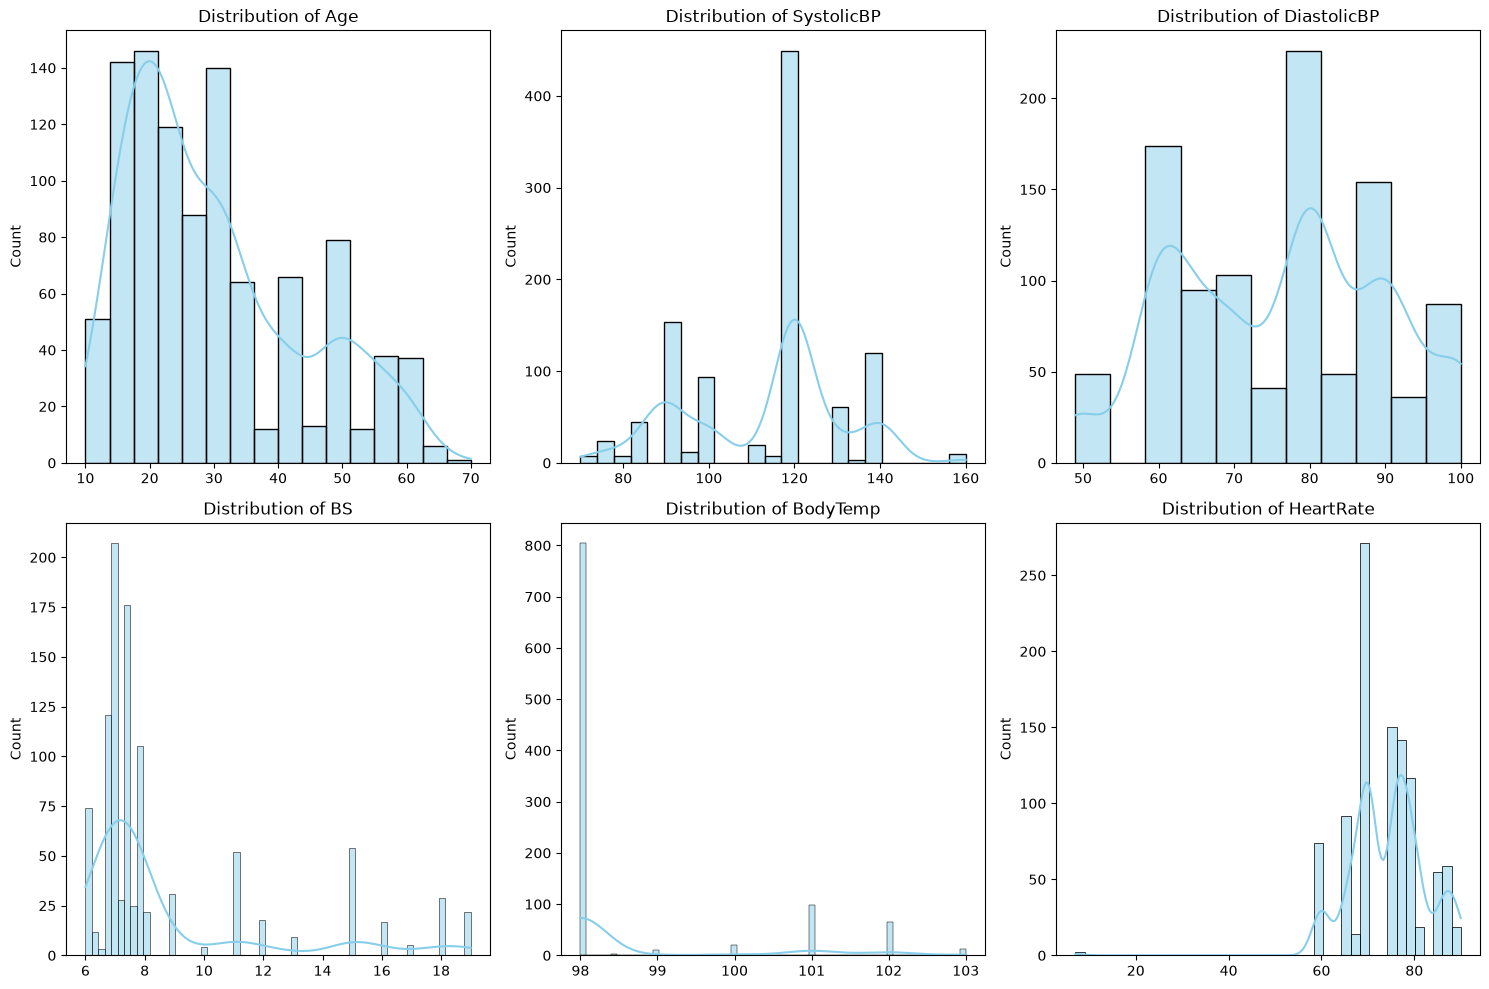

In [10]:
features = ['Age','SystolicBP','DiastolicBP','BS','BodyTemp','HeartRate']
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15,10))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig('histograms.png', dpi=300)
plt.show()

/tmp/ipykernel_25704/543613398.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='RiskLevel', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_25704/543613398.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='RiskLevel', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_25704/543613398.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='RiskLevel', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_25704/543613398.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be

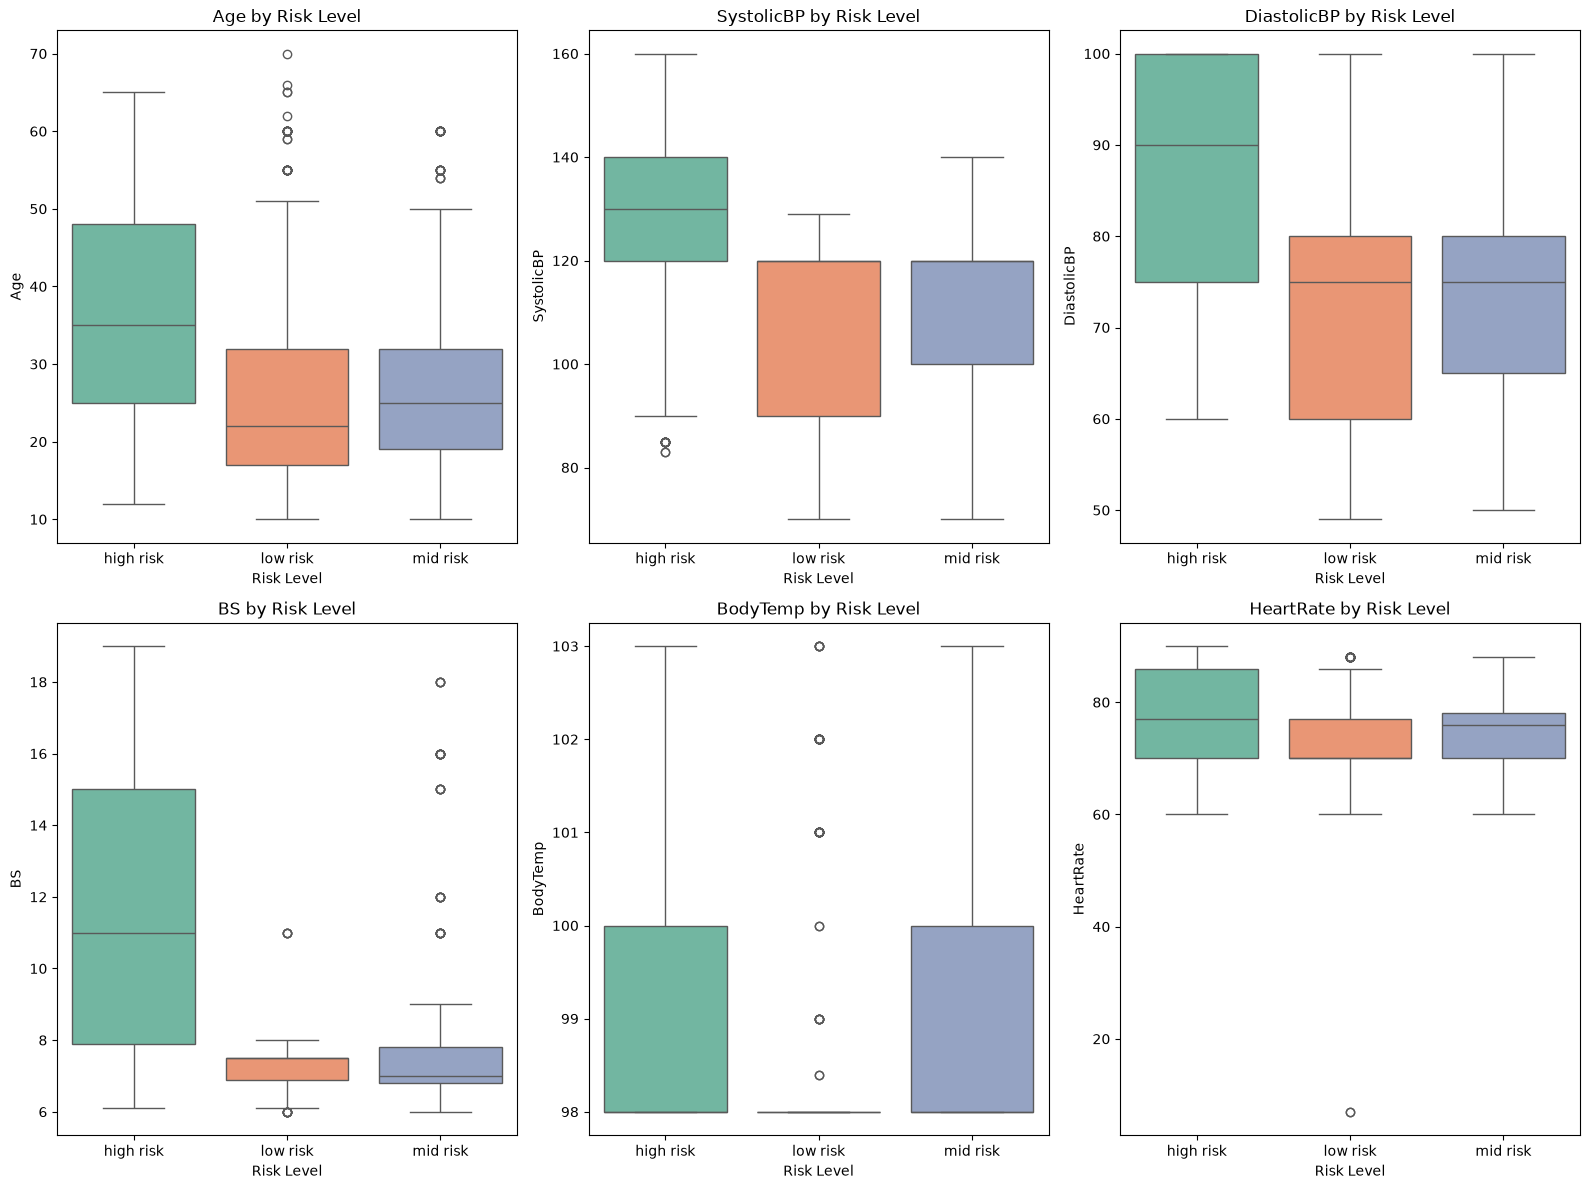

In [11]:
features = ['Age','SystolicBP','DiastolicBP','BS','BodyTemp','HeartRate']
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16,12))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.boxplot(data=df, x='RiskLevel', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} by Risk Level', fontsize=12)
    axes[i].set_xlabel('Risk Level')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.savefig('box_plots_by_risk.png')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

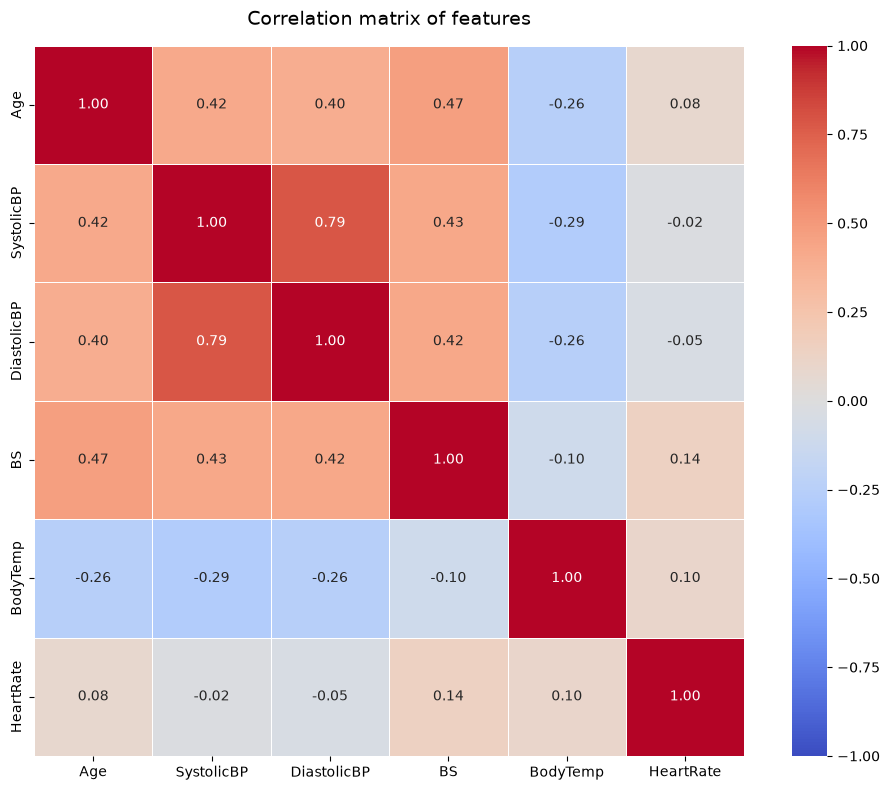

In [12]:
corr_matrix= df.drop(columns=['RiskLevel']).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True, linewidth=0.5)
plt.title('Correlation matrix of features', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show

In [17]:
from sklearn.model_selection import train_test_split
x = df.drop(columns='RiskLevel')
y = df['RiskLevel']

x_train, x_test, y_train, y_ = train_test_split(x, y, test_size = 0.2, stratify = y)
print(f"Training Set: {x_train.shape}")
print(f"Test set: {x_test.shape}")
print(f"Y train value count: {y_train.value_counts()}")
print(f"Y test value count: {y_test.value_counts()}")


Training Set: (811, 6)
Test set: (203, 6)
Y train value count: RiskLevel
low risk     325
mid risk     269
high risk    217
Name: count, dtype: int64
Y test value count: RiskLevel
low risk     81
mid risk     67
high risk    55
Name: count, dtype: int64


In [20]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_sm, y_train_sm = smote.fit_resample(x_train, y_train)
print(f"X train: {x_train_sm.shape}")
print(f" Y train: {y_train_sm.value_counts()}")

X train: (975, 6)
 Y train: RiskLevel
low risk     325
mid risk     325
high risk    325
Name: count, dtype: int64
